# What is practice worth?

Two questions, both answerable now that the model solves in seconds.

1. If I get more accurate, how much better do I actually get?
2. Should I practise doubles or trebles?

## Choosing the model

A club match is a race in **visits**, so that is the currency: the 3-dart MDP
with the minimum-visits objective. It solves in about ten seconds per ability,
which makes a dense sweep affordable, and notebook 04 established it is within
about 1.4 points of win probability of the full two-player game.

The second question needs something the model did not previously support:
accuracy that depends on **where you are aiming**. That cannot go through a
single FFT, because every aiming point would need its own kernel. It does not
have to -- partition the aiming grid into doubles, trebles and everything else,
and run one FFT per class.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts import players
from darts.mdp_3turn import ThreeDartMDP
from darts.practice import (classify_points, practice_split_value,
                            sigma_sensitivity, transition_arrays_by_class)
from darts.transitions import transition_arrays

SIGMAS = np.arange(6.0, 30.1, 1.0)
visits = []
for sigma in SIGMAS:
    tr = transition_arrays(players.BOARD_PIXELS, float(sigma), point_stride=4)
    m = ThreeDartMDP(tr['probs'], tr['checkout_probs'], tr['allowed_scores'],
                     players.GAME_START, dart_cost=0.0, turn_cost=1.0).solve()
    visits.append(-m.V1[players.GAME_START])
visits = np.array(visits)
print(f'solved {len(SIGMAS)} abilities')

solved 25 abilities


,sigma,visits,points per visit,visits saved per mm
band,,,,
elite,6.5,5.32,94.2,0.434
pro,8.0,5.98,83.8,0.448
county,10.0,6.91,72.5,0.495
super_league,13.0,8.49,59.0,0.549
league,16.0,10.21,49.1,0.580
club,20.0,12.49,40.1,0.566
pub,28.0,17.05,29.4,0.583


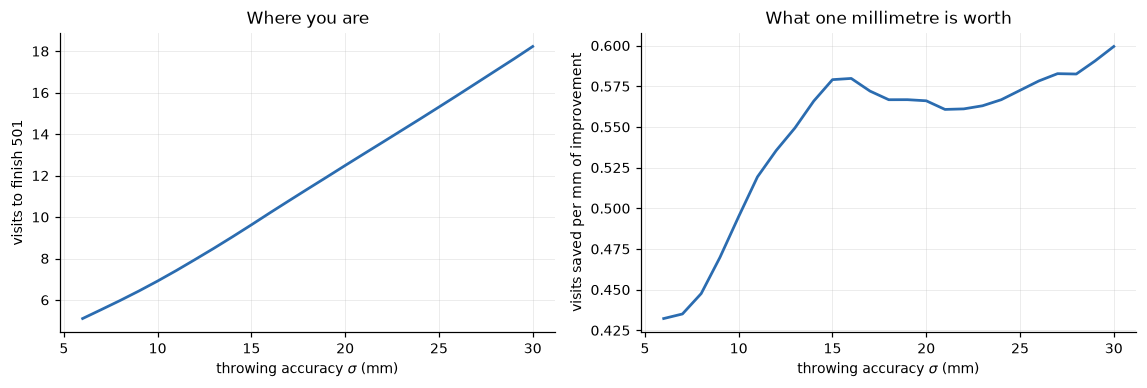

In [2]:
d_visits = sigma_sensitivity(SIGMAS, visits)
avg = 3 * players.GAME_START / (visits * 3)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
axes[0].plot(SIGMAS, visits, color='#2b6cb0', lw=1.8)
axes[0].set_xlabel(r'throwing accuracy $\sigma$ (mm)')
axes[0].set_ylabel('visits to finish 501')
axes[0].set_title('Where you are')

axes[1].plot(SIGMAS, d_visits, color='#2b6cb0', lw=1.8)
axes[1].set_xlabel(r'throwing accuracy $\sigma$ (mm)')
axes[1].set_ylabel('visits saved per mm of improvement')
axes[1].set_title('What one millimetre is worth')
fig.tight_layout()

rows = [{'band': b, 'sigma': s,
         'visits': round(float(np.interp(s, SIGMAS, visits)), 2),
         'points per visit': round(501 / np.interp(s, SIGMAS, visits), 1),
         'visits saved per mm': round(float(sigma_sensitivity(SIGMAS, visits, at=s)), 3)}
        for b, s in players.ABILITY_BANDS.items()]
pd.DataFrame(rows).set_index('band')

Note that "points per visit" is not the same as a 3-dart average: the last visit of a leg
is usually a partial one, so 501 divided by visits understates the published figure by
several points. The band averages in `darts/players.py` are computed the proper way, from
darts thrown.

The return on accuracy is remarkably **flat**. Each millimetre is worth between 0.43 and
0.58 visits per leg across the entire range from elite to pub. It is worth slightly more at
the weak end, but nothing like as much more as one might expect -- there is no point at
which improvement suddenly stops paying.

That is worth knowing because the usual intuition is the opposite: that beginners improve
in leaps and good players grind for tiny gains. In *accuracy* terms that is true, since a
millimetre is much harder to find when you are already tight. But per millimetre found, the
payoff barely changes.

## Reference: the solved value of every ability band

The sweep above is deliberately coarse -- a stride-4 aiming grid, so a dense sigma range is
affordable. `scripts/solve_single_player.py` solves each shared ability band properly, at
the full ~29,000-point aiming grid and both objectives, and writes
`results/manifest_single_player.csv`. Those are the authoritative numbers this project
quotes elsewhere, so they are worth having in one table.

Two objectives are solved because they answer different questions. **Darts** to finish 501
is the number that maps onto a published 3-dart average; **visits** is the currency of a
race against an opponent, and is what notebook 06's match model consumes.

In [3]:
manifest = pd.read_csv(os.path.join(module_path, 'results', 'manifest_single_player.csv'))

wide = manifest.pivot(index=['band', 'sigma_mm'], columns='objective',
                      values='value_501')
extra = (manifest[manifest.objective == 'darts']
         .set_index(['band', 'sigma_mm'])[['three_dart_average', 'darts_from_170',
                                           'darts_from_40', 'aiming_points']])
ref = wide.join(extra).reset_index()
ref = ref.sort_values('sigma_mm').set_index('band')
ref.columns = ['sigma (mm)', 'darts to finish 501', 'visits to finish 501',
               '3-dart average', 'darts from 170', 'darts from 40', 'aiming points']
ref.round(3)

,sigma (mm),darts to finish 501,visits to finish 501,3-dart average,darts from 170,darts from 40,aiming points
band,,,,,,,
elite,6.5,15.012,5.321,100.12,6.199,2.222,29497
pro,8.0,16.918,5.974,88.84,7.163,2.712,29669
county,10.0,19.649,6.904,76.49,8.444,3.413,29829
super_league,13.0,24.167,8.470,62.19,10.571,4.638,30065
league,16.0,28.984,10.187,51.86,12.982,6.141,30349
club,20.0,35.128,12.472,42.79,16.509,8.606,30661
pub,28.0,46.491,17.023,32.33,24.470,15.111,31381


The last two columns are the ones a player would feel, and the comparison between them is
the whole argument of this notebook in two numbers.

**Darts from 40** -- a straightforward double-16 finish -- costs an elite player 2.2 darts
and a pub player **15.1**, a factor of 6.8. **Darts from 170** costs 6.2 against 24.5, a
factor of 4.0. So the gap between the best and worst players is *wider on the easy finish
than on the hard one*.

That is not the intuitive way round, and it is the same result as the doubles-versus-trebles
crossover below, seen from another angle. Reaching 170 and dealing with it is a scoring
problem, and weak players are bad at scoring in a fairly proportionate way. Closing out from
40 is a *doubles* problem, and there the weak player is not merely slower -- they arrive at
the finish and then fail to convert it, visit after visit. The bottleneck is conversion, not
accumulation.

Note that the visits column is not the darts column divided by three. A leg ends mid-visit,
so the last visit is usually a partial one; dividing 501 by visits understates a published
3-dart average by several points, which is why both objectives are solved rather than one
being converted into the other.

In [4]:
rows = []
for band in ['county', 'league', 'club', 'pub']:
    for r in practice_split_value(players.ABILITY_BANDS[band], improvement=0.2,
                                  point_stride=4):
        rows.append({'band': band, **r})
split = pd.DataFrame(rows)
split.pivot(index='band', columns='scenario', values='visits saved')[
    ['doubles only', 'trebles only', 'everything']].reindex(
    ['county', 'league', 'club', 'pub'])

scenario,doubles only,trebles only,everything
band,,,
county,0.3332,0.6594,0.9397
league,0.8263,1.1525,1.8264
club,1.1491,1.1898,2.2778
pub,2.0160,1.0459,3.2119


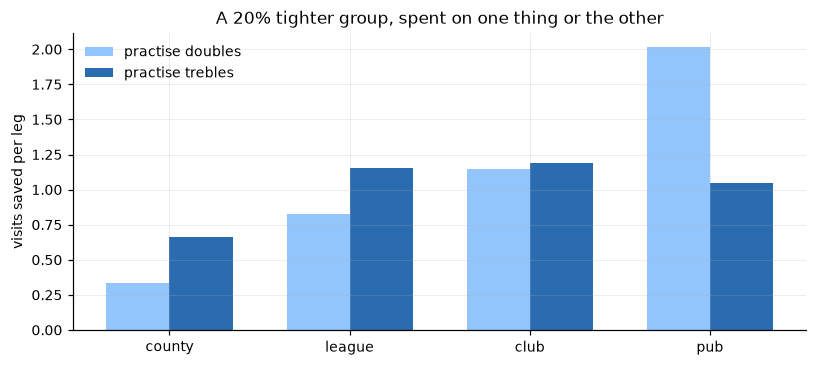

In [5]:
piv = split.pivot(index='band', columns='scenario',
                  values='visits saved').reindex(['county', 'league', 'club', 'pub'])
fig, ax = plt.subplots(figsize=(7.5, 3.4))
w = 0.35
x = np.arange(len(piv))
ax.bar(x - w/2, piv['doubles only'], w, label='practise doubles', color='#93c5fd')
ax.bar(x + w/2, piv['trebles only'], w, label='practise trebles', color='#2b6cb0')
ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel('visits saved per leg')
ax.set_title('A 20% tighter group, spent on one thing or the other')
ax.legend()
fig.tight_layout()

**It crosses over, and that is the interesting part.**

For a county or league player, trebles are clearly the better investment -- roughly twice
as valuable for the league player. By club level the two are level. For a pub player,
doubles are worth **twice** as much as trebles.

The reason is that the two abilities bind at different times. A strong player reaches a
finishing position most visits, so their leg length is set by how fast they score: improve
the trebles. A weak player's problem is not getting to a double, it is *converting* one --
they arrive at a checkout and then spend visit after visit failing to close it, so the
doubles are the bottleneck.

So the folk advice "practise your doubles" is right for the people most likely to be given
it, and wrong for the people who repeat it. Both halves of that are worth saying.

In [6]:
from darts.match import FORMATS, match_win_probability
from darts.practice import leg_win_probability

base = players.ABILITY_BANDS['league']
opp_visits = float(np.interp(base, SIGMAS, visits))
rows = []
for delta in [0.0, 0.5, 1.0, 2.0, 3.0]:
    my_visits = float(np.interp(base - delta, SIGMAS, visits))
    p1 = leg_win_probability(my_visits, opp_visits, throws_first=True)
    p2 = leg_win_probability(my_visits, opp_visits, throws_first=False)
    rows.append({'sigma improvement (mm)': delta,
                 'my visits': round(my_visits, 2),
                 'P(win leg, throwing)': round(p1, 4),
                 'P(win best of 11)': round(
                     match_win_probability(p1, p2, **FORMATS['best of 11 legs (Premier League, UK Open early)']), 4)})
pd.DataFrame(rows).set_index('sigma improvement (mm)')

,my visits,"P(win leg, throwing)",P(win best of 11)
sigma improvement (mm),,,
0.0,10.21,0.5257,0.5063
0.5,9.92,0.5338,0.5272
1.0,9.63,0.5421,0.5485
2.0,9.05,0.5591,0.5920
3.0,8.49,0.5767,0.6361


## Summary

* A millimetre of accuracy is worth 0.43--0.58 visits per leg, and that figure is
  surprisingly flat across the whole range of ability.
* **Whether to practise doubles or trebles depends on how good you are.** Trebles for
  county and league players, roughly level at club standard, and doubles -- by a factor of
  two -- for a pub player.
* Which means the model settles an argument that folk wisdom gets half right: the
  bottleneck is scoring for strong players and finishing for weak ones.
* All of this assumes your doubles accuracy currently equals your trebles accuracy. For a
  player with a genuine doubles problem that is the assumption that fails, and notebook 07
  is how you would measure it instead.